In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.5_all_data.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.5_all_data.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.5_all_data.tsv", sep="\t")

fold2_05["fold"] = [0 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
fold0_04 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.4_all_data.tsv", sep="\t")

fold0_04["fold"] = [0 for i in range(len(fold0_04))]
fold0_04["target"] = [-0.4 for i in range(len(fold0_04))]

In [6]:
fold1_04 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.4_all_data.tsv", sep="\t")

fold1_04["fold"] = [1 for i in range(len(fold1_04))]
fold1_04["target"] = [-0.4 for i in range(len(fold1_04))]

In [7]:
fold2_04 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.4_all_data.tsv", sep="\t")

fold2_04["fold"] = [2 for i in range(len(fold2_04))]
fold2_04["target"] = [-0.4 for i in range(len(fold2_04))]

In [8]:
fold0_03 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.3_all_data.tsv", sep="\t")

fold0_03["fold"] = [0 for i in range(len(fold0_03))]
fold0_03["target"] = [-0.3 for i in range(len(fold0_03))]

In [9]:
fold1_03 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.3_all_data.tsv", sep="\t")

fold1_03["fold"] = [1 for i in range(len(fold1_03))]
fold1_03["target"] = [-0.3 for i in range(len(fold1_03))]

In [10]:
fold2_03 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.3_all_data.tsv", sep="\t")

fold2_03["fold"] = [2 for i in range(len(fold2_03))]
fold2_03["target"] = [-0.3 for i in range(len(fold2_03))]

In [11]:
fold0_02 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.2_all_data_extra.tsv", sep="\t")

fold0_02["fold"] = [0 for i in range(len(fold0_02))]
fold0_02["target"] = [-0.2 for i in range(len(fold0_02))]

In [12]:
fold1_02 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.2_all_data_extra.tsv", sep="\t")

fold1_02["fold"] = [1 for i in range(len(fold1_02))]
fold1_02["target"] = [-0.2 for i in range(len(fold1_02))]

In [13]:
fold2_02 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.2_all_data_extra.tsv", sep="\t")

fold2_02["fold"] = [2 for i in range(len(fold2_02))]
fold2_02["target"] = [-0.2 for i in range(len(fold2_02))]

In [14]:
df = pd.concat([fold0_05, fold1_05, fold2_05, fold0_04, fold1_04, fold2_04, fold0_03, fold1_03, fold2_03, fold0_02, fold1_02, fold2_02], ignore_index=True)

In [15]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'active_count', 'neutral_count',
       'repressive_count', 'total', 'active_fraction', 'neutral_fraction',
       'repressive_fraction', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'fold', 'target', 'orientation',
       'positions'],
      dtype='object')

In [16]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [17]:
df['optimization_successful'] = df['SCD'] > 30

In [18]:
natural_results_path = "/scratch1/smaruj/natural_boundaries_URQmean/all_boundaries_URQ_mean.tsv"
nat_df = pd.read_csv(natural_results_path, sep="\t")

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

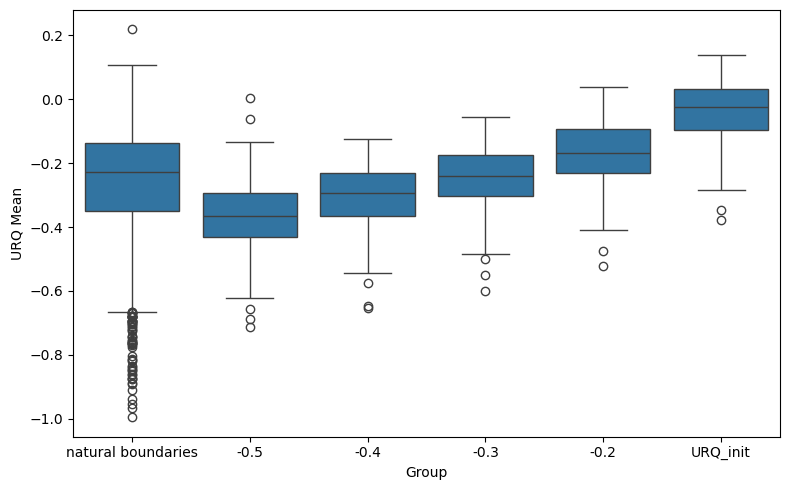

In [20]:
# 1. URQ_result for all targets
plot_df = df[['URQ_result', 'target']].copy()
plot_df['value'] = plot_df['URQ_result']
plot_df['group'] = plot_df['target'].astype(str)

# 3. URQ_mean from nat_df
nat_df_box = pd.DataFrame({
    'value': nat_df['URQ_mean'],
    'group': ['natural boundaries'] * len(nat_df)
})

# 2. URQ_init for target -0.5
init_subset = df[df['target'] == -0.5]
init_df = pd.DataFrame({
    'value': init_subset['URQ_init'],
    'group': ['URQ_init'] * len(init_subset)
})

# 4. Combine in desired order: URQ_mean, URQ_init, then URQ_result
combined_df = pd.concat(
    [nat_df_box, plot_df[['value', 'group']], init_df],
    ignore_index=True
)

# 5. Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='value', data=combined_df)
plt.xlabel("Group")
plt.ylabel("URQ Mean")
plt.tight_layout()
plt.show()


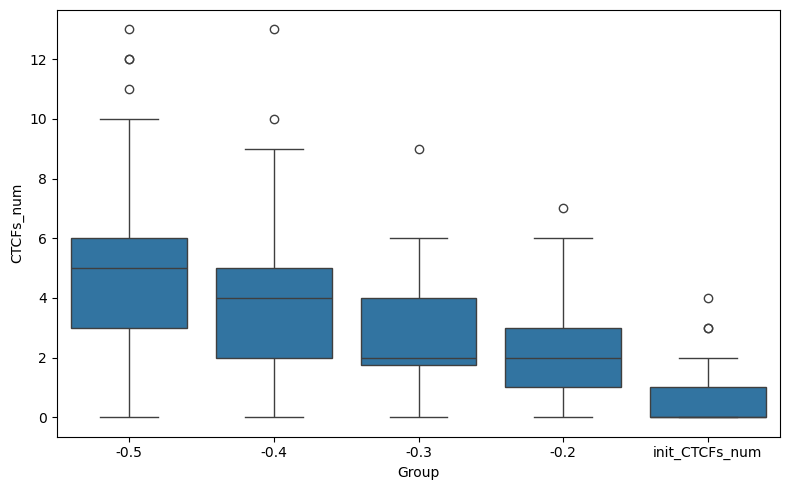

In [21]:
# 1. CTCFs_num for all targets
plot_df = df[['CTCFs_num', 'target']].copy()
plot_df['value'] = plot_df['CTCFs_num']
plot_df['group'] = plot_df['target'].astype(str)

# 2. init_CTCFs_num for target -0.5
init_subset = df[df['target'] == -0.5]
init_df = pd.DataFrame({
    'value': init_subset['init_CTCFs_num'],
    'group': ['init_CTCFs_num'] * len(init_subset)
})

# 3. Combine
combined_df = pd.concat([plot_df[['value', 'group']], init_df], ignore_index=True)

# 4. Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='value', data=combined_df)
plt.xlabel("Group")
plt.ylabel("CTCFs_num")
# plt.title("CTCFs_num by Target Category with Initial CTCFs_num (-0.5)")
plt.tight_layout()
plt.show()

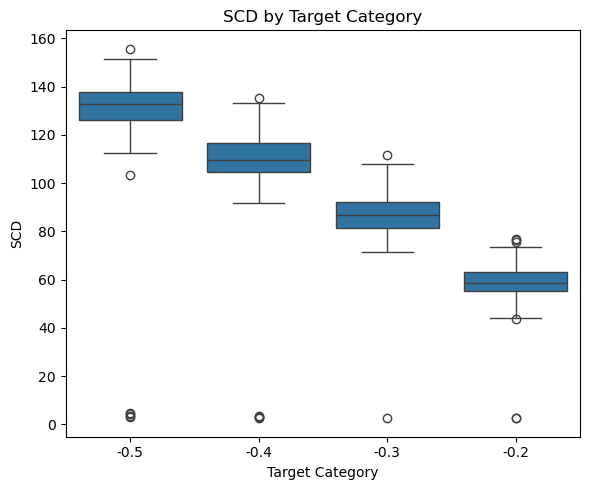

In [22]:
plot_df = df[['SCD', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='SCD', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("SCD")
plt.title("SCD by Target Category")
plt.tight_layout()
plt.show()

Pearson correlation: r = -0.345, p = 6.16e-06


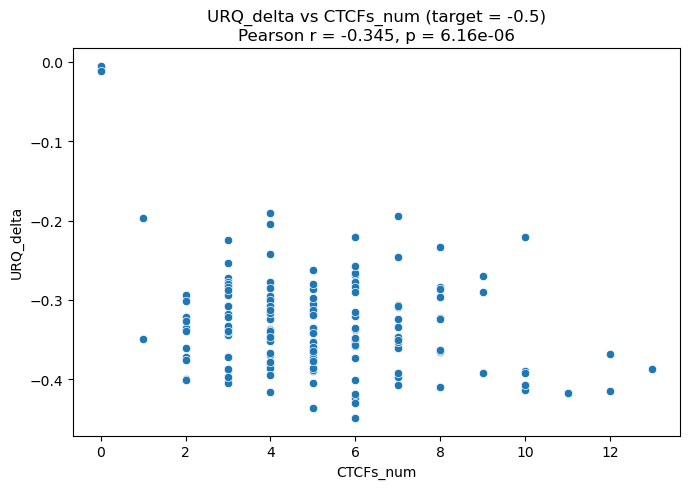

In [23]:
from scipy.stats import pearsonr

# 1. Subset to target -0.5
subset = df[df['target'] == -0.5].copy()

# 2. Compute URQ_delta
subset['URQ_delta'] = subset['URQ_result'] - subset['URQ_init']

# 3. Pearson correlation
corr, pval = pearsonr(subset['CTCFs_num'], subset['URQ_delta'])
print(f"Pearson correlation: r = {corr:.3f}, p = {pval:.3g}")

# 4. Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=subset,
    x='CTCFs_num',
    y='URQ_delta'
)
plt.xlabel("CTCFs_num")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs CTCFs_num (target = -0.5)\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.tight_layout()
plt.show()

Pearson correlation (with initial): r = -0.825, p = 1.21e-82


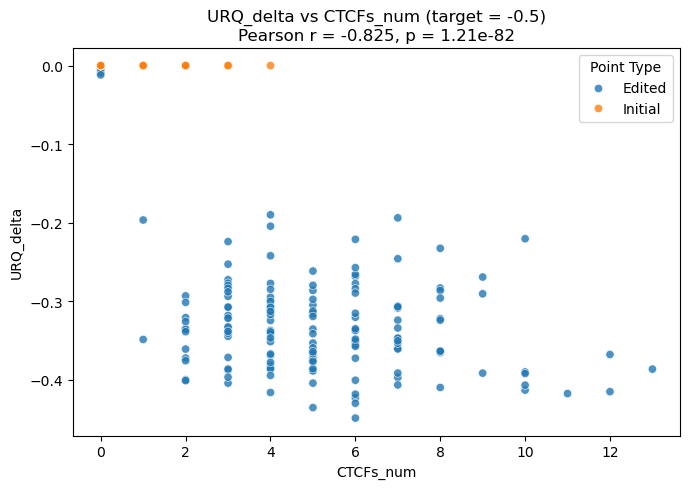

In [24]:
# 1. Subset to target -0.5
subset = df[df['target'] == -0.5].copy()
subset['URQ_delta'] = subset['URQ_result'] - subset['URQ_init']
subset['Type'] = 'Edited'

# 2. Add init_CTCFs_num with URQ_delta = 0.0
init_df = pd.DataFrame({
    'CTCFs_num': df.loc[df['target'] == -0.5, 'init_CTCFs_num'],
    'URQ_delta': 0.0,
    'Type': 'Initial'
})

# 3. Combine both
plot_df = pd.concat([subset[['CTCFs_num', 'URQ_delta', 'Type']], init_df], ignore_index=True)

# 4. Pearson correlation on full set
corr, pval = pearsonr(plot_df['CTCFs_num'], plot_df['URQ_delta'])
print(f"Pearson correlation (with initial): r = {corr:.3f}, p = {pval:.3g}")

# 5. Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=plot_df,
    x='CTCFs_num',
    y='URQ_delta',
    hue='Type',
    palette={'Edited': 'C0', 'Initial': 'C1'},
    alpha=0.8
)
plt.xlabel("CTCFs_num")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs CTCFs_num (target = -0.5)\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.legend(title="Point Type")
plt.tight_layout()
plt.show()

Pearson correlation: r = -0.304, p = 7.77e-05


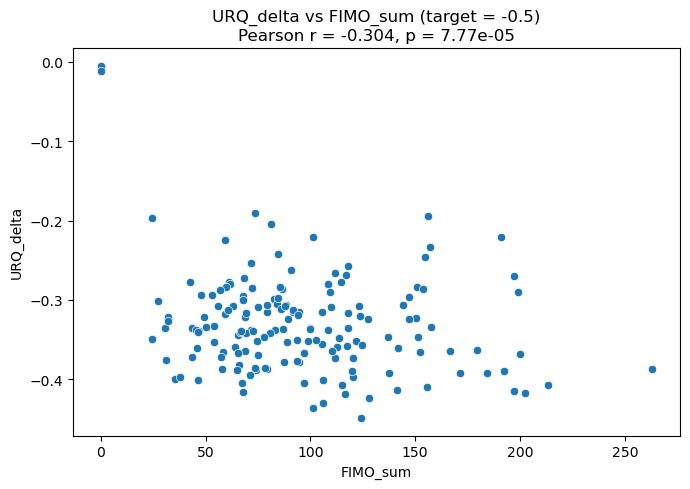

In [25]:
from scipy.stats import pearsonr

# 1. Subset to target -0.5
subset = df[df['target'] == -0.5].copy()

# 3. Pearson correlation
corr, pval = pearsonr(subset['FIMO_sum'], subset['URQ_delta'])
print(f"Pearson correlation: r = {corr:.3f}, p = {pval:.3g}")

# 4. Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=subset,
    x='FIMO_sum',
    y='URQ_delta'
)
plt.xlabel("FIMO_sum")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs FIMO_sum (target = -0.5)\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.tight_layout()
plt.show()

Pearson correlation (all targets + init): r = -0.603, p = 3.48e-66


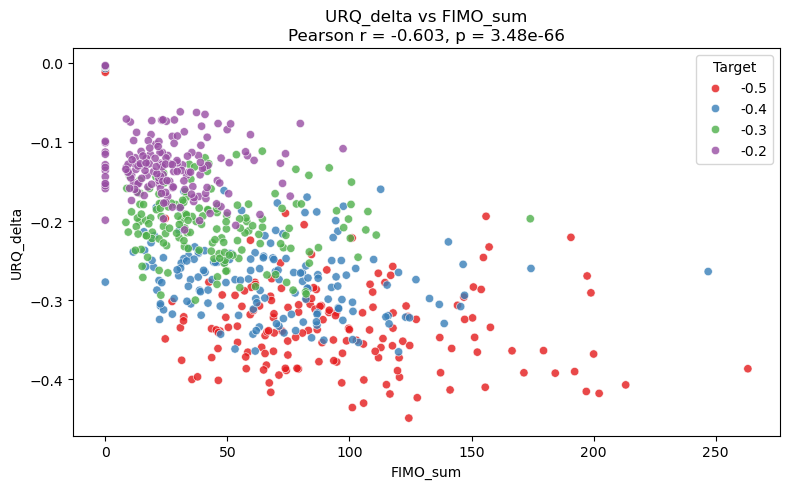

In [26]:
# 1. Compute URQ_delta for all relevant targets
subset = df[df['target'].isin([-0.5, -0.4, -0.3, -0.2])].copy()
subset['URQ_delta'] = subset['URQ_result'] - subset['URQ_init']
subset['Target'] = subset['target'].astype(str)  # Treat target as group label

# 3. Combine all data
plot_df = pd.concat([subset[['FIMO_sum', 'URQ_delta', 'Target']]], ignore_index=True)

# # 4. Pearson correlation over full data
corr, pval = pearsonr(plot_df['FIMO_sum'], plot_df['URQ_delta'])
print(f"Pearson correlation (all targets + init): r = {corr:.3f}, p = {pval:.3g}")

# 5. Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x='FIMO_sum',
    y='URQ_delta',
    hue='Target',
    palette='Set1',
    alpha=0.8
)
plt.xlabel("FIMO_sum")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs FIMO_sum\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.legend(title="Target")
plt.tight_layout()
plt.show()


Pearson correlation (all targets + init): r = -0.558, p = 5.1e-55


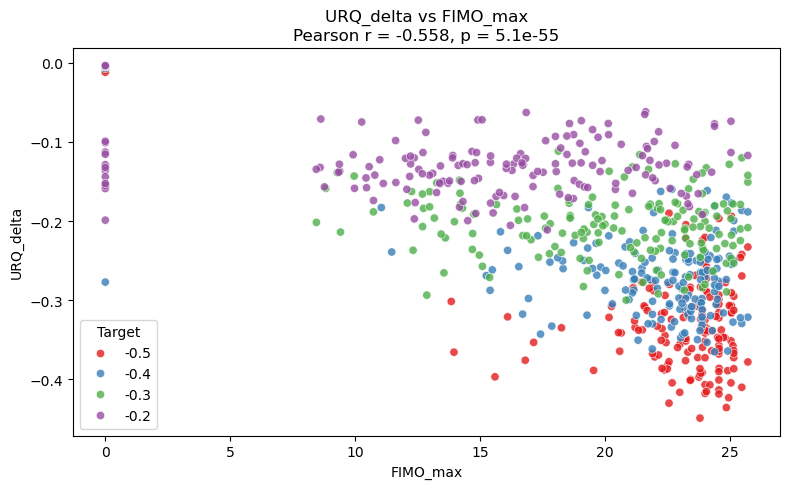

In [27]:
# 1. Compute URQ_delta for all relevant targets
subset = df[df['target'].isin([-0.5, -0.4, -0.3, -0.2])].copy()
subset['URQ_delta'] = subset['URQ_result'] - subset['URQ_init']
subset['Target'] = subset['target'].astype(str)  # Treat target as group label

# 3. Combine all data
plot_df = pd.concat([subset[['FIMO_max', 'URQ_delta', 'Target']]], ignore_index=True)

# # 4. Pearson correlation over full data
corr, pval = pearsonr(plot_df['FIMO_max'], plot_df['URQ_delta'])
print(f"Pearson correlation (all targets + init): r = {corr:.3f}, p = {pval:.3g}")

# 5. Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x='FIMO_max',
    y='URQ_delta',
    hue='Target',
    palette='Set1',
    alpha=0.8
)
plt.xlabel("FIMO_max")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs FIMO_max\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

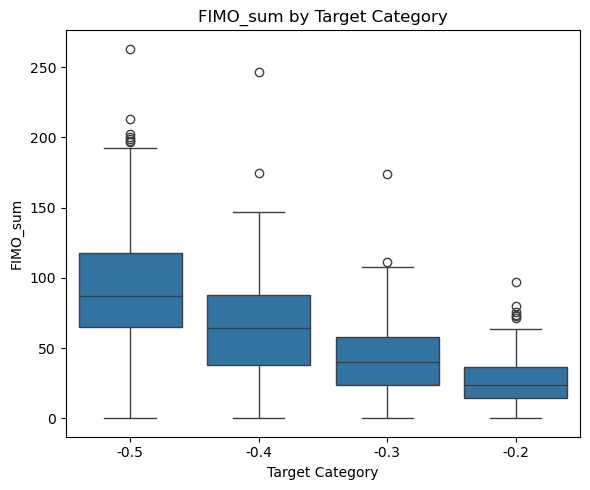

In [28]:
plot_df = df[['FIMO_sum', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='FIMO_sum', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by Target Category")
plt.tight_layout()
plt.show()

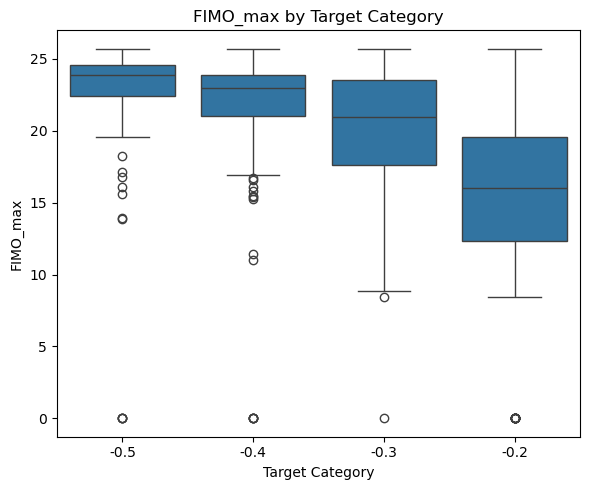

In [29]:
plot_df = df[['FIMO_max', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='FIMO_max', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by Target Category")
plt.tight_layout()
plt.show()

In [30]:
natural_results_path = "/scratch1/smaruj/natural_boundaries_URQmean/all_boundaries_URQ_mean.tsv"
nat_df = pd.read_csv(natural_results_path, sep="\t")

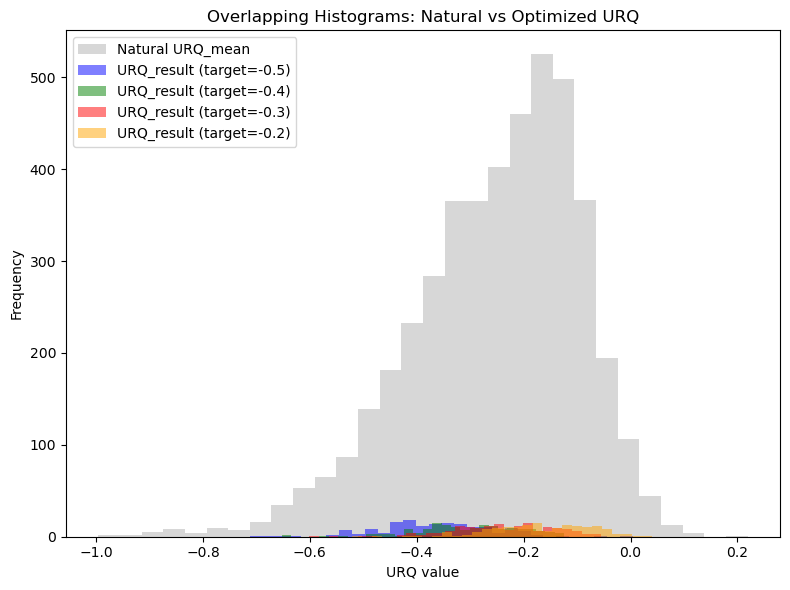

In [32]:
targets = [-0.5, -0.4, -0.3, -0.2]
colors = { -0.5: 'blue', -0.4: 'green', -0.3: 'red', -0.2: 'orange' }

plt.figure(figsize=(8, 6))

# Background histogram from natural data
plt.hist(nat_df["URQ_mean"], bins=30, color='lightgray', alpha=0.9, label='Natural URQ_mean')

# Overlay histograms for each target
for target in targets:
    subset = df[df["target"] == target]["URQ_result"]
    plt.hist(subset, bins=30, alpha=0.5, label=f'URQ_result (target={target})', color=colors[target])

plt.xlabel("URQ value")
plt.ylabel("Frequency")
plt.title("Overlapping Histograms: Natural vs Optimized URQ")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'active_count', 'neutral_count',
       'repressive_count', 'total', 'active_fraction', 'neutral_fraction',
       'repressive_fraction', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'fold', 'target', 'orientation',
       'positions', 'URQ_delta', 'optimization_successful'],
      dtype='object')

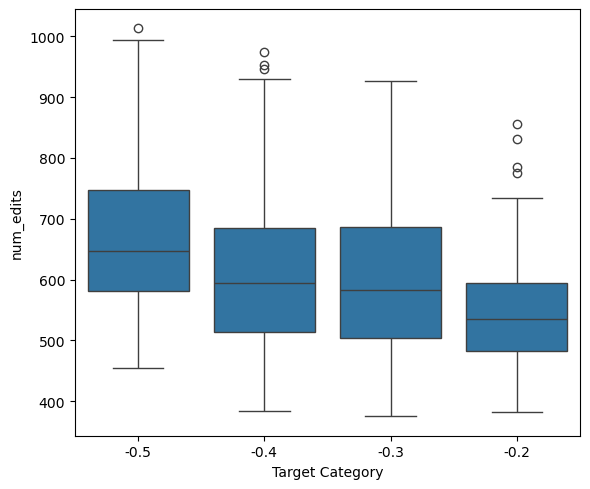

In [34]:
plot_df = df[['num_edits', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='num_edits', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("num_edits")
# plt.title("num_edits by Target Category")
plt.tight_layout()
plt.show()

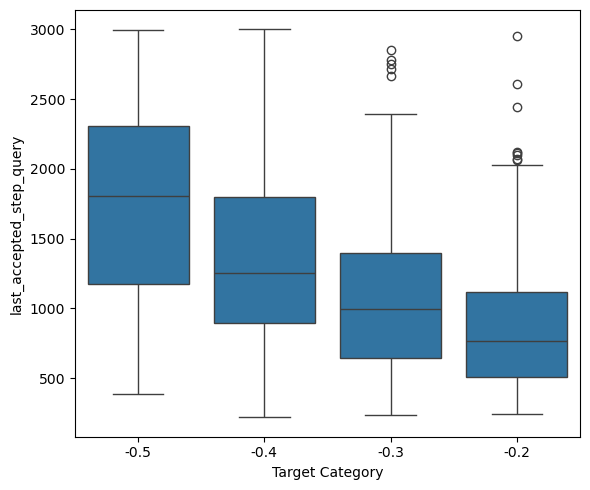

In [35]:
plot_df = df[['last_accepted_step_query', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='last_accepted_step_query', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("last_accepted_step_query")
# plt.title("num_edits by Target Category")
plt.tight_layout()
plt.show()

In [37]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'active_count', 'neutral_count',
       'repressive_count', 'total', 'active_fraction', 'neutral_fraction',
       'repressive_fraction', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'fold', 'target', 'orientation',
       'positions', 'URQ_delta', 'optimization_successful'],
      dtype='object')

In [38]:
df[df["target"] == -0.2]["CTCFs_num"].mean()

1.8902439024390243

In [39]:
df[df["target"] == -0.3]["CTCFs_num"].mean()

2.707317073170732

In [40]:
df[df["target"] == -0.4]["CTCFs_num"].mean()

3.8048780487804876

In [41]:
df[df["target"] == -0.5]["CTCFs_num"].mean()

5.0426829268292686